# Anthropic Salary Analysis

Analysis of salary data scraped from Anthropic's Greenhouse job board.

In [ ]:
# ── CONFIG ──────────────────────────────────────────────────────────
CSV_PATH = "anthropic_salaries.csv"
# ────────────────────────────────────────────────────────────────────

import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from bs4 import BeautifulSoup

from classify import (
    classify_department, classify_seniority, classify_work_mode,
    add_classifications, add_usd_salary, TO_USD, SENIORITY_ORDER,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Data Loading & Cleaning

The scraper's regex misses most salaries because `salary_text` contains raw HTML.
We re-parse it here to extract actual numeric ranges.

In [ ]:
df_raw = pd.read_csv(CSV_PATH, dtype={"job_id": str})
print(f"Total jobs loaded: {len(df_raw)}")
df_raw.head()

In [3]:
def extract_salary_from_html(text: str) -> dict:
    """Re-extract salary min/max/currency from the salary_text HTML fragments."""
    if pd.isna(text) or not text.strip():
        return {"salary_min": None, "salary_max": None, "currency": None, "salary_unit": None}

    # Strip HTML tags to get plain text
    plain = BeautifulSoup(text, "html.parser").get_text(" ", strip=True)
    plain = re.sub(r"\s+", " ", plain).strip()

    # Detect unit
    unit = None
    if re.search(r"\bAnnual\b|\bper year\b|\byearly\b", plain, re.I):
        unit = "annual"
    elif re.search(r"\bhour\b|\bhourly\b", plain, re.I):
        unit = "hourly"

    # Detect currency code
    currency = None
    m_code = re.search(r"\b(USD|EUR|GBP|CAD|AUD)\b", plain)
    if m_code:
        currency = m_code.group(1)

    # Pattern: $172,300 — $222,800  or  €155.000 — €205.000
    dash = r"(?:\u2013|\u2014|-|\u2014|\s+to\s+)"
    # USD-style: commas as thousand separators
    m = re.search(
        rf"[\$£€]\s*(\d{{1,3}}(?:,\d{{3}})+)\s*{dash}\s*[\$£€]?\s*(\d{{1,3}}(?:,\d{{3}})+)",
        plain,
    )
    if m:
        sym_match = re.search(r"[\$£€]", plain)
        sym = sym_match.group(0) if sym_match else None
        if not currency and sym:
            currency = {"$": "USD", "€": "EUR", "£": "GBP"}.get(sym)
        return {
            "salary_min": int(m.group(1).replace(",", "")),
            "salary_max": int(m.group(2).replace(",", "")),
            "currency": currency,
            "salary_unit": unit,
        }

    # EUR-style: dots as thousand separators (e.g. €155.000 — €205.000)
    m2 = re.search(
        rf"[\$£€]\s*(\d{{1,3}}(?:\.\d{{3}})+)\s*{dash}\s*[\$£€]?\s*(\d{{1,3}}(?:\.\d{{3}})+)",
        plain,
    )
    if m2:
        sym_match = re.search(r"[\$£€]", plain)
        sym = sym_match.group(0) if sym_match else None
        if not currency and sym:
            currency = {"$": "USD", "€": "EUR", "£": "GBP"}.get(sym)
        return {
            "salary_min": int(m2.group(1).replace(".", "")),
            "salary_max": int(m2.group(2).replace(".", "")),
            "currency": currency,
            "salary_unit": unit,
        }

    # Bare numbers with currency code: 131,040 – 165,000 USD
    m3 = re.search(
        rf"(\d{{1,3}}(?:,\d{{3}})+|\d+)\s*{dash}\s*(\d{{1,3}}(?:,\d{{3}})+|\d+)\s*(USD|EUR|GBP|CAD|AUD)",
        plain,
    )
    if m3:
        return {
            "salary_min": int(m3.group(1).replace(",", "")),
            "salary_max": int(m3.group(2).replace(",", "")),
            "currency": m3.group(3),
            "salary_unit": unit,
        }

    return {"salary_min": None, "salary_max": None, "currency": currency, "salary_unit": unit}


parsed = df_raw["salary_text"].apply(extract_salary_from_html).apply(pd.Series)
df = df_raw[["job_id", "title", "location", "url", "updated_at"]].copy()
df[["salary_min", "salary_max", "currency", "salary_unit"]] = parsed

df_salary = df.dropna(subset=["salary_min", "salary_max"]).copy()
df_salary["salary_mid"] = (df_salary["salary_min"] + df_salary["salary_max"]) / 2

print(f"Jobs with parsed salary ranges: {len(df_salary)} / {len(df)}")
print(f"Currencies found: {df_salary['currency'].value_counts().to_dict()}")
df_salary.head()

Jobs with parsed salary ranges: 397 / 442
Currencies found: {'USD': 333, 'GBP': 38, 'EUR': 26}


,job_id,title,location,url,updated_at,salary_min,salary_max,currency,salary_unit,salary_mid
0,5074975008,Account Coordinator,"New York City, NY; San Francisco, CA",https://job-boards.greenhouse.io/anthropic/job...,2026-02-23T17:11:43-05:00,172300.0,222800.0,USD,annual,197550.0
1,5101832008,"Account Executive, Academic Medical Centers - ...","San Francisco, CA",https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,290000.0,435000.0,USD,annual,362500.0
2,4978301008,"Account Executive, Mid Market, German","Dublin, IE",https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,155000.0,205000.0,EUR,annual,180000.0
3,4948535008,"Account Executive, Mid Market UKI","Dublin, IE",https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,155000.0,205000.0,EUR,annual,180000.0
4,4978296008,"Account Executive, Mid Market - UKI","Dublin, IE",https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,155000.0,205000.0,EUR,annual,180000.0


### Currency Conversion

Hardcoded exchange rates for reproducibility. Update these if re-running later.

In [4]:
# Convert salaries to USD using rates from classify.py
print("Exchange rates used (to USD):")
for k, v in TO_USD.items():
    print(f"  1 {k} = {v} USD")

add_usd_salary(df_salary)

Exchange rates used (to USD):
  1 USD = 1.0 USD
  1 EUR = 1.05 USD
  1 GBP = 1.27 USD
  1 CAD = 0.72 USD
  1 AUD = 0.64 USD


,job_id,title,location,url,updated_at,salary_min,salary_max,currency,salary_unit,salary_mid,rate,min_usd,max_usd,mid_usd
0,5074975008,Account Coordinator,"New York City, NY; San Francisco, CA",https://job-boards.greenhouse.io/anthropic/job...,2026-02-23T17:11:43-05:00,172300.0,222800.0,USD,annual,197550.0,1.00,172300.0,222800.0,197550.0
1,5101832008,"Account Executive, Academic Medical Centers - ...","San Francisco, CA",https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,290000.0,435000.0,USD,annual,362500.0,1.00,290000.0,435000.0,362500.0
2,4978301008,"Account Executive, Mid Market, German","Dublin, IE",https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,155000.0,205000.0,EUR,annual,180000.0,1.05,162750.0,215250.0,189000.0
3,4948535008,"Account Executive, Mid Market UKI","Dublin, IE",https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,155000.0,205000.0,EUR,annual,180000.0,1.05,162750.0,215250.0,189000.0
4,4978296008,"Account Executive, Mid Market - UKI","Dublin, IE",https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,155000.0,205000.0,EUR,annual,180000.0,1.05,162750.0,215250.0,189000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,5097351008,Training Content and Systems Architect,"San Francisco, CA | New York City, NY",https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,270000.0,365000.0,USD,annual,317500.0,1.00,270000.0,365000.0,317500.0
438,5099080008,Transaction Manager,Remote-Friendly (Travel-Required) | San Franci...,https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,365000.0,435000.0,USD,annual,400000.0,1.00,365000.0,435000.0,400000.0
439,5117612008,Transfer Pricing Director,Remote-Friendly (Travel Required) | San Franci...,https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,230000.0,300000.0,USD,annual,265000.0,1.00,230000.0,300000.0,265000.0
440,5114845008,"Video Director, Product Launches","San Francisco, CA",https://job-boards.greenhouse.io/anthropic/job...,2026-02-20T18:33:18-05:00,200000.0,255000.0,USD,annual,227500.0,1.00,200000.0,255000.0,227500.0


## 2. Summary Statistics

In [5]:
print("=" * 60)
print("PER-CURRENCY STATISTICS (native values)")
print("=" * 60)
for cur, grp in df_salary.groupby("currency"):
    print(f"\n--- {cur} ({len(grp)} roles) ---")
    for label, col in [("Min salary", "salary_min"), ("Max salary", "salary_max"), ("Midpoint", "salary_mid")]:
        vals = grp[col]
        print(f"  {label:12s}  min={vals.min():>10,.0f}  max={vals.max():>10,.0f}  "
              f"mean={vals.mean():>10,.0f}  median={vals.median():>10,.0f}  std={vals.std():>10,.0f}")

PER-CURRENCY STATISTICS (native values)

--- EUR (26 roles) ---
  Min salary    min=    85,000  max=   300,000  mean=   186,346  median=   190,000  std=    51,586
  Max salary    min=    95,000  max=   375,000  mean=   225,385  median=   220,000  std=    64,373
  Midpoint      min=    90,000  max=   337,500  mean=   205,865  median=   196,250  std=    57,532

--- GBP (38 roles) ---
  Min salary    min=    75,000  max=   325,000  mean=   203,026  median=   172,500  std=    67,389
  Max salary    min=   100,000  max=   630,000  mean=   277,000  median=   215,000  std=   133,236
  Midpoint      min=    87,500  max=   445,000  mean=   240,013  median=   190,000  std=    95,110

--- USD (333 roles) ---
  Min salary    min=   115,000  max=   500,000  mean=   287,505  median=   290,000  std=    72,004
  Max salary    min=   130,000  max=   850,000  mean=   390,937  median=   365,000  std=   149,349
  Midpoint      min=   122,500  max=   675,000  mean=   339,221  median=   327,500  std=   103,

In [6]:
print("=" * 60)
print("UNIFIED USD STATISTICS (all roles converted)")
print("=" * 60)
for label, col in [("Min salary", "min_usd"), ("Max salary", "max_usd"), ("Midpoint", "mid_usd")]:
    vals = df_salary[col]
    print(f"  {label:12s}  min=${vals.min():>10,.0f}  max=${vals.max():>10,.0f}  "
          f"mean=${vals.mean():>10,.0f}  median=${vals.median():>10,.0f}  std=${vals.std():>10,.0f}")

UNIFIED USD STATISTICS (all roles converted)
  Min salary    min=$    89,250  max=$   500,000  mean=$   278,651  median=$   290,000  std=$    76,000
  Max salary    min=$    99,750  max=$   850,000  mean=$   377,086  median=$   360,000  std=$   152,254
  Midpoint      min=$    94,500  max=$   675,000  mean=$   327,868  median=$   320,000  std=$   107,419


## 3. Salary Distribution

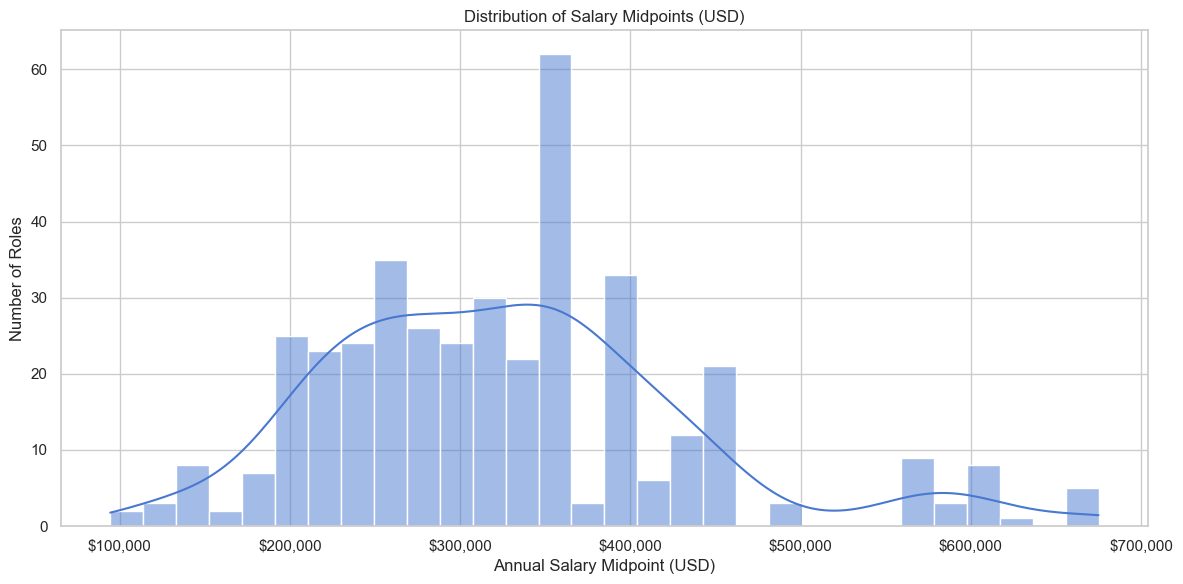

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df_salary["mid_usd"], bins=30, kde=True, ax=ax)
ax.set_title("Distribution of Salary Midpoints (USD)")
ax.set_xlabel("Annual Salary Midpoint (USD)")
ax.set_ylabel("Number of Roles")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

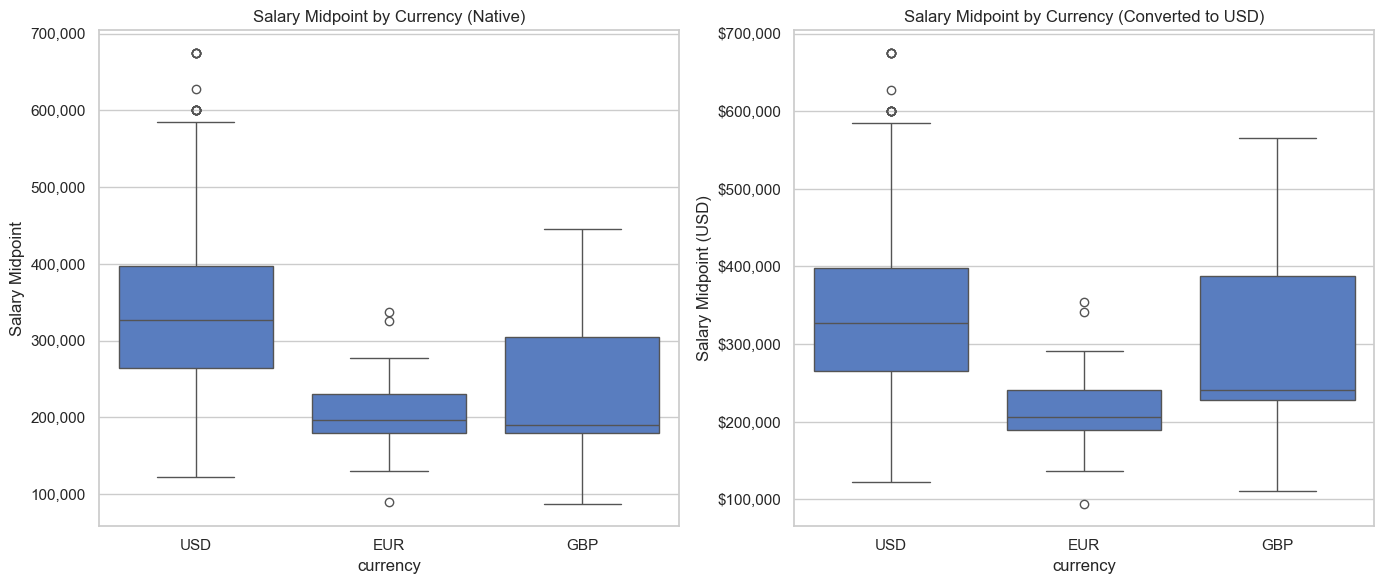

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Native currency box plot
sns.boxplot(data=df_salary, x="currency", y="salary_mid", ax=axes[0])
axes[0].set_title("Salary Midpoint by Currency (Native)")
axes[0].set_ylabel("Salary Midpoint")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# USD-converted box plot
sns.boxplot(data=df_salary, x="currency", y="mid_usd", ax=axes[1])
axes[1].set_title("Salary Midpoint by Currency (Converted to USD)")
axes[1].set_ylabel("Salary Midpoint (USD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

## 4. Location Analysis

Multi-location roles are split so each city is counted individually.

In [9]:
def split_locations(loc: str) -> list[str]:
    """Split multi-location strings on | or ; and normalize."""
    if pd.isna(loc):
        return ["Unknown"]
    parts = re.split(r"[|;]", loc)
    return [p.strip() for p in parts if p.strip()]


# Explode for all jobs (role counts per city)
df_loc_all = df.copy()
df_loc_all["city"] = df_loc_all["location"].apply(split_locations)
df_loc_all = df_loc_all.explode("city")

# Explode for salary jobs (salary by city)
df_loc_sal = df_salary.copy()
df_loc_sal["city"] = df_loc_sal["location"].apply(split_locations)
df_loc_sal = df_loc_sal.explode("city")

print(f"Unique cities (all jobs): {df_loc_all['city'].nunique()}")
print(f"Unique cities (with salary): {df_loc_sal['city'].nunique()}")

Unique cities (all jobs): 22
Unique cities (with salary): 15


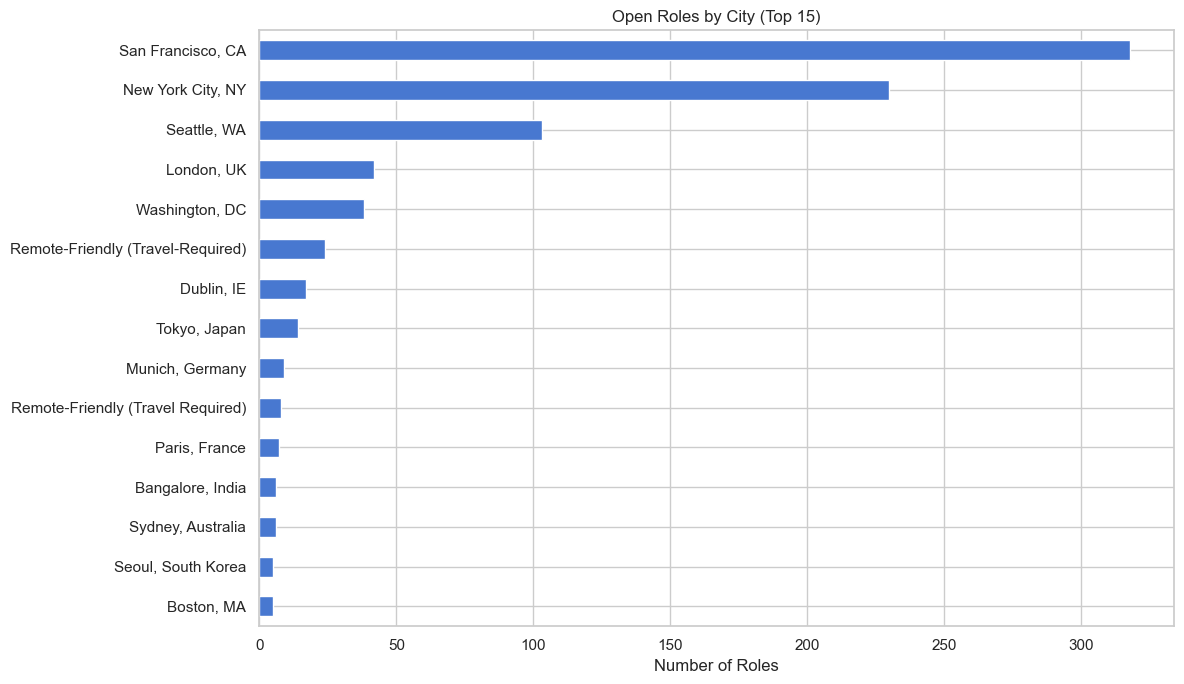

In [10]:
top_cities = df_loc_all["city"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
top_cities.plot.barh(ax=ax)
ax.set_title("Open Roles by City (Top 15)")
ax.set_xlabel("Number of Roles")
ax.set_ylabel("")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

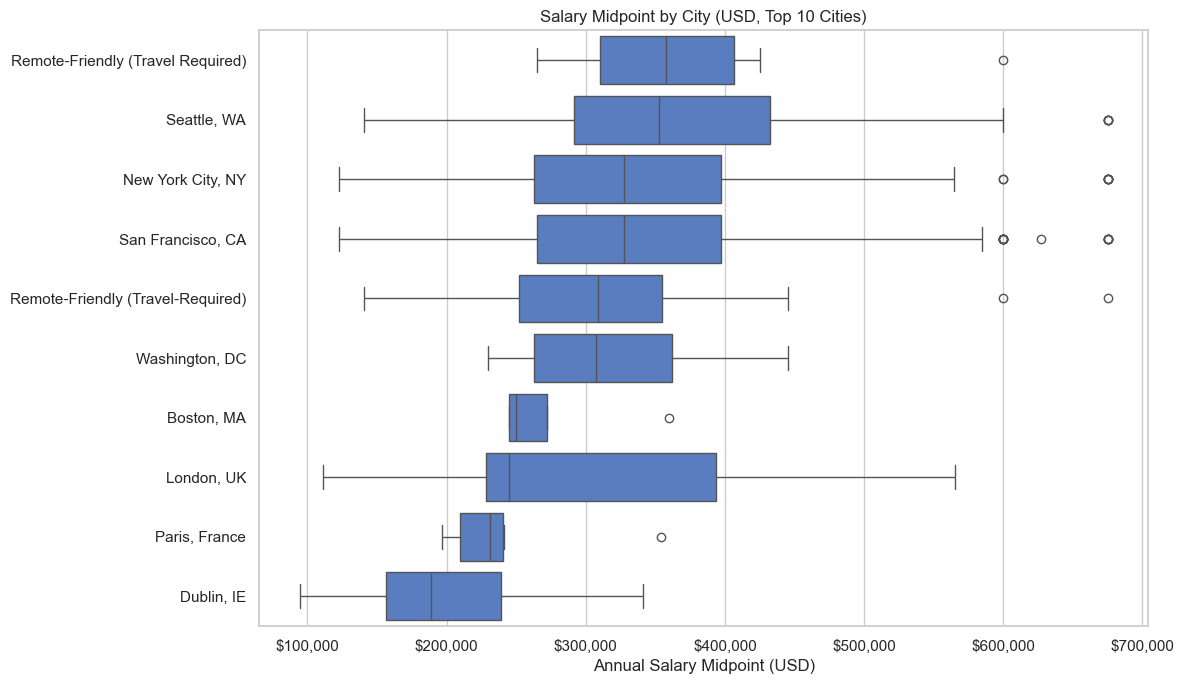

In [11]:
# Top 10 cities by number of roles with salary data
top_salary_cities = df_loc_sal["city"].value_counts().head(10).index.tolist()
df_plot = df_loc_sal[df_loc_sal["city"].isin(top_salary_cities)]

# Order by median salary
city_order = df_plot.groupby("city")["mid_usd"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(data=df_plot, y="city", x="mid_usd", order=city_order, ax=ax)
ax.set_title("Salary Midpoint by City (USD, Top 10 Cities)")
ax.set_xlabel("Annual Salary Midpoint (USD)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## 5. Role-Level Analysis

In [12]:
sorted_roles = df_salary.sort_values("mid_usd", ascending=False)

print("TOP 10 HIGHEST PAYING ROLES (USD)")
print("=" * 80)
for _, r in sorted_roles.head(10).iterrows():
    print(f"  ${r['mid_usd']:>10,.0f}  (${r['min_usd']:,.0f} - ${r['max_usd']:,.0f})  {r['title']}")

print(f"\nBOTTOM 10 LOWEST PAYING ROLES (USD)")
print("=" * 80)
for _, r in sorted_roles.tail(10).iterrows():
    print(f"  ${r['mid_usd']:>10,.0f}  (${r['min_usd']:,.0f} - ${r['max_usd']:,.0f})  {r['title']}")

TOP 10 HIGHEST PAYING ROLES (USD)
  $   675,000  ($500,000 - $850,000)  Engineering Manager, ML Acceleration
  $   675,000  ($500,000 - $850,000)  Staff Machine Learning Engineer, Virtual Collaborator
  $   675,000  ($500,000 - $850,000)  Research Engineer, Universes
  $   675,000  ($500,000 - $850,000)  Machine Learning Systems Engineer, RL Engineering
  $   675,000  ($500,000 - $850,000)  Research Engineer, Machine Learning (Reinforcement Learning) 
  $   627,500  ($405,000 - $850,000)  Research Engineer, Frontier Red Team (Hardware Lead)
  $   600,000  ($350,000 - $850,000)  Research Engineer, Discovery
  $   600,000  ($350,000 - $850,000)  Research Engineer / Research Scientist, Vision
  $   600,000  ($350,000 - $850,000)  Research Engineer, Pretraining Scaling
  $   600,000  ($350,000 - $850,000)  Research Engineer, Pre-training

BOTTOM 10 LOWEST PAYING ROLES (USD)
  $   140,740  ($116,480 - $165,000)  Product Support Specialist
  $   140,740  ($116,480 - $165,000)  Product Suppor

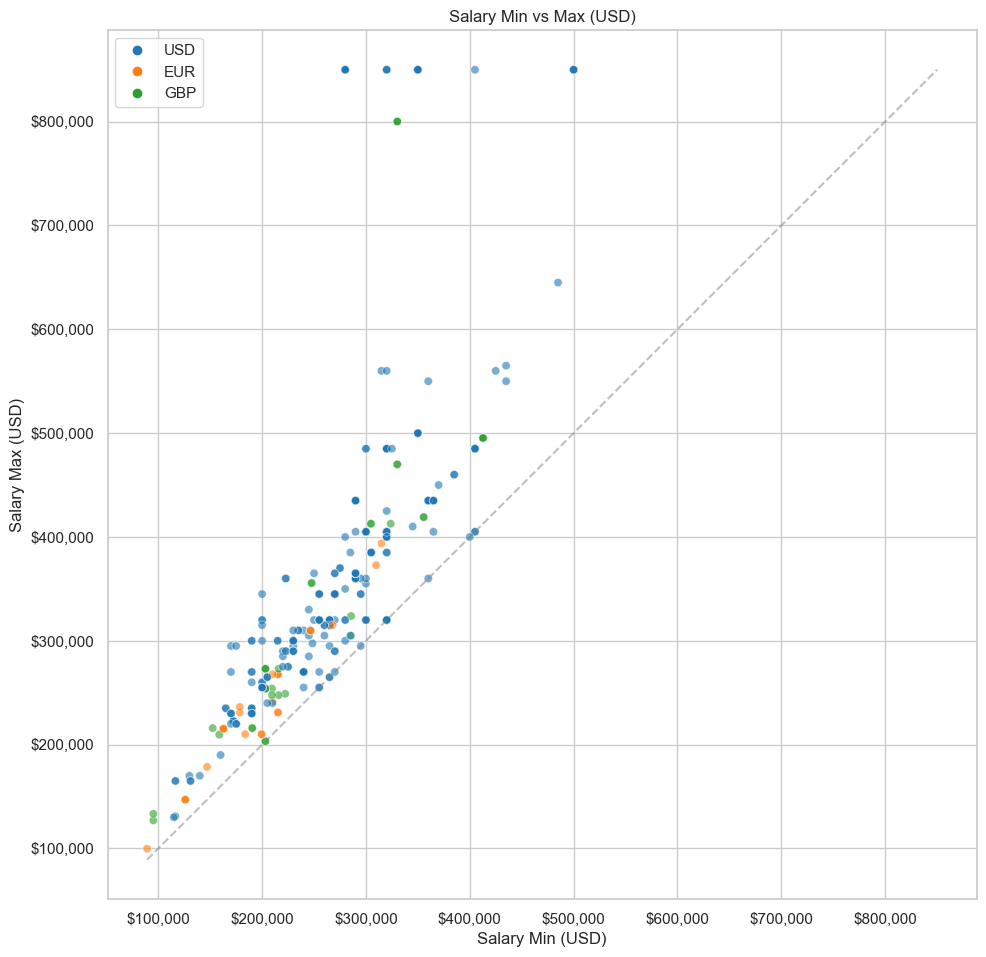

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    df_salary["min_usd"],
    df_salary["max_usd"],
    c=df_salary["currency"].map({"USD": "#1f77b4", "EUR": "#ff7f0e", "GBP": "#2ca02c"}),
    alpha=0.6,
    edgecolors="white",
    linewidth=0.5,
)

# Diagonal reference line (min == max, i.e. no range)
lims = [df_salary["min_usd"].min(), df_salary["max_usd"].max()]
ax.plot(lims, lims, "--", color="gray", alpha=0.5, label="min = max")

ax.set_title("Salary Min vs Max (USD)")
ax.set_xlabel("Salary Min (USD)")
ax.set_ylabel("Salary Max (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Legend for currencies
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#1f77b4", markersize=8, label="USD"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#ff7f0e", markersize=8, label="EUR"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2ca02c", markersize=8, label="GBP"),
]
ax.legend(handles=handles)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

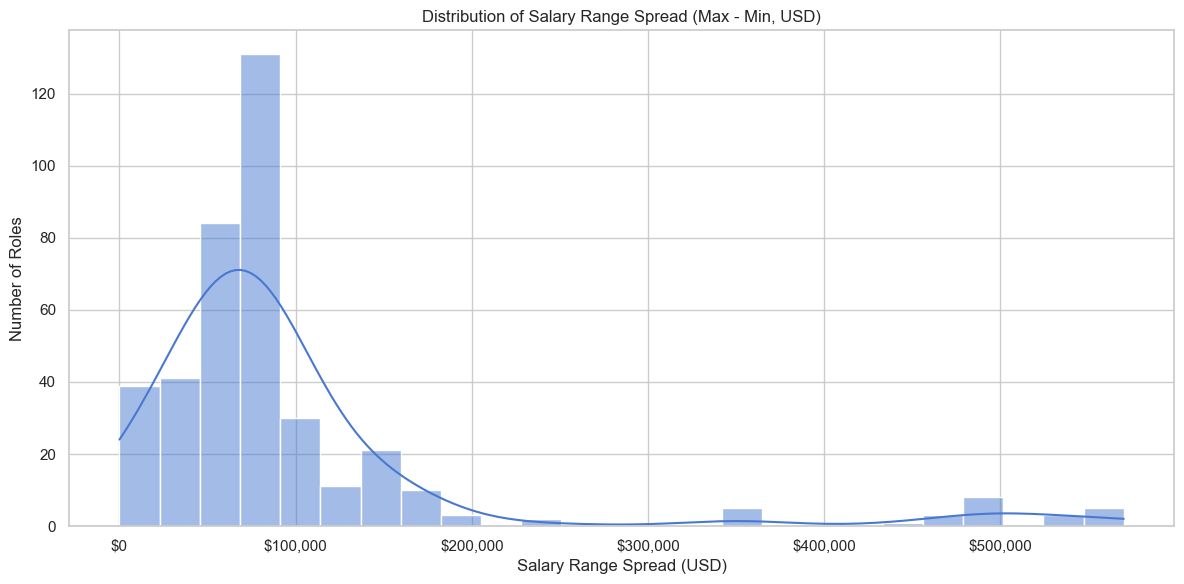


Median range spread: $75,000
Mean range spread:   $98,435


In [14]:
df_salary["range_usd"] = df_salary["max_usd"] - df_salary["min_usd"]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(df_salary["range_usd"], bins=25, kde=True, ax=ax)
ax.set_title("Distribution of Salary Range Spread (Max - Min, USD)")
ax.set_xlabel("Salary Range Spread (USD)")
ax.set_ylabel("Number of Roles")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

print(f"\nMedian range spread: ${df_salary['range_usd'].median():,.0f}")
print(f"Mean range spread:   ${df_salary['range_usd'].mean():,.0f}")

## 6. Department / Category Analysis

Categorize each role into a functional department based on title keywords.

In [15]:
# Classify departments using rules from classify.py
df_salary["department"] = df_salary["title"].apply(classify_department)
df["department"] = df["title"].apply(classify_department)

dept_counts = df["department"].value_counts()
print("ROLE COUNTS BY DEPARTMENT (all jobs)")
print("=" * 50)
for dept, cnt in dept_counts.items():
    print(f"  {dept:<42s} {cnt:>4d}")
print(f"  {'TOTAL':<42s} {len(df):>4d}")

ROLE COUNTS BY DEPARTMENT (all jobs)
  Sales                                       121
  AI Research & Engineering                    56
  Marketing & Brand                            31
  Finance                                      31
  Software Engineering - Infrastructure        30
  Security                                     29
  Engineering & Design - Product               29
  Product Management, Support, & Operations    16
  Other                                        16
  People                                       15
  Safeguards (Trust & Safety)                  13
  Legal                                        13
  Compute                                      13
  Technical Program Management                 13
  AI Public Policy & Societal Impacts          12
  Data Science & Analytics                      2
  Communications                                2
  TOTAL                                       442


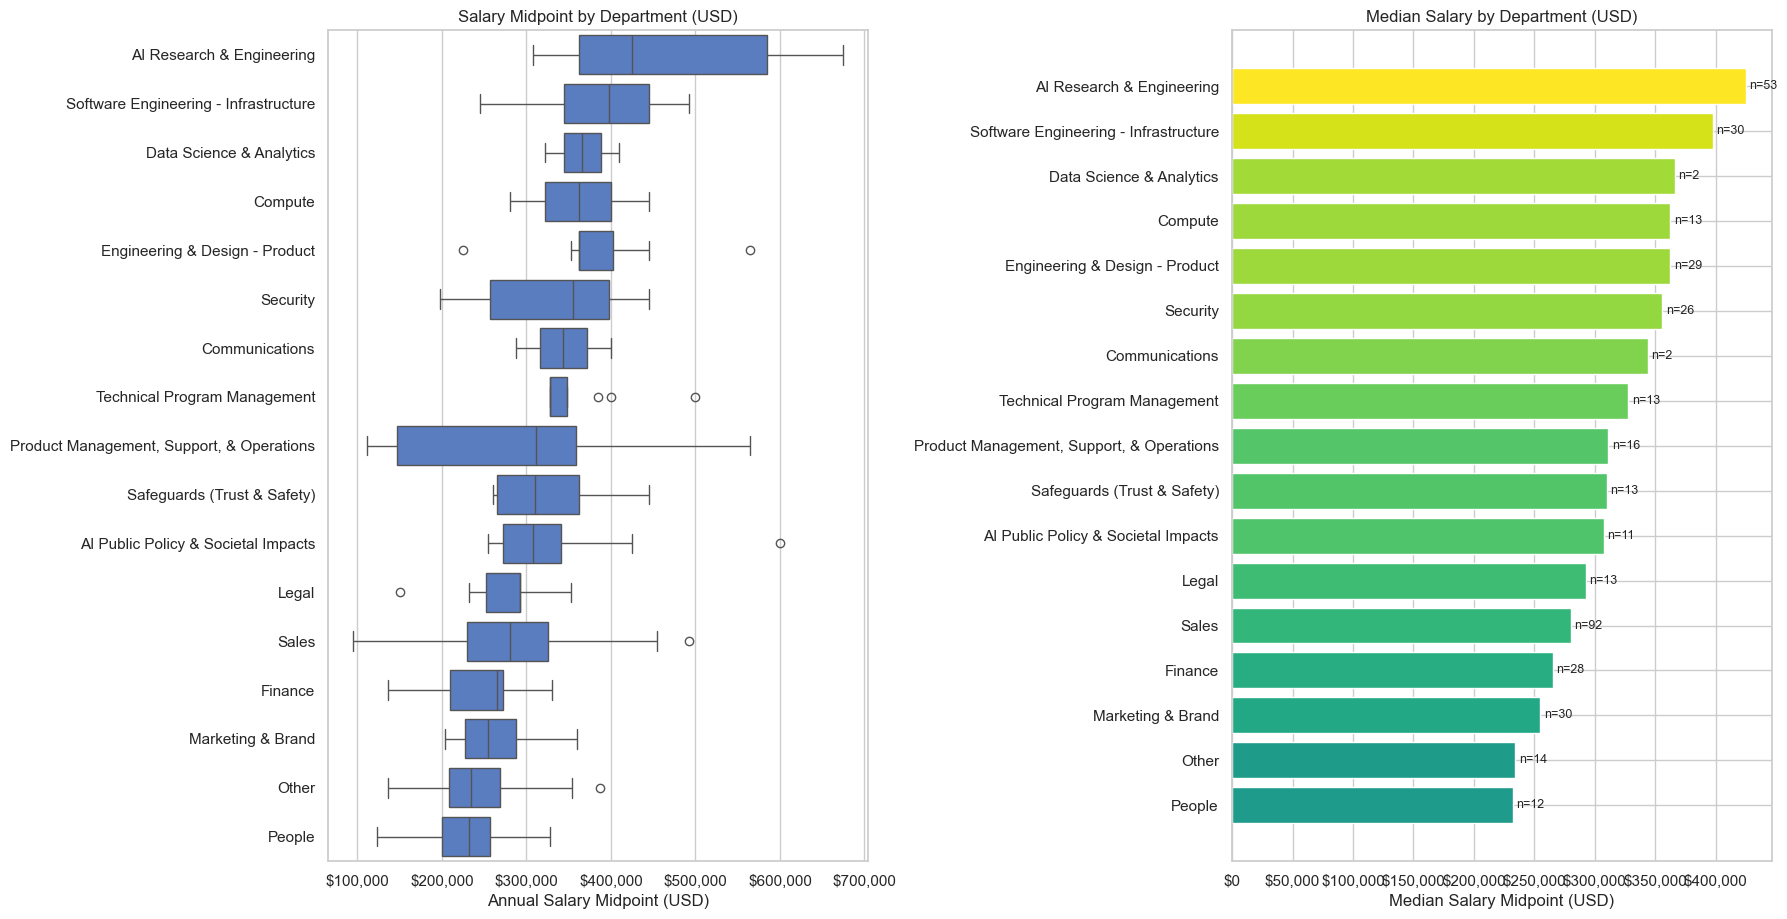

In [16]:
# Salary distribution by department
dept_order = (
    df_salary.groupby("department")["mid_usd"]
    .median()
    .sort_values(ascending=False)
    .index
)
n_depts = len(dept_order)

fig, axes = plt.subplots(1, 2, figsize=(18, max(7, n_depts * 0.55)))

# Box plot
sns.boxplot(data=df_salary, y="department", x="mid_usd", order=dept_order, ax=axes[0])
axes[0].set_title("Salary Midpoint by Department (USD)")
axes[0].set_xlabel("Annual Salary Midpoint (USD)")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Count + median bar chart
dept_stats = (
    df_salary.groupby("department")["mid_usd"]
    .agg(["median", "count"])
    .reindex(dept_order)
)
colors = plt.cm.viridis(dept_stats["median"] / dept_stats["median"].max())
bars = axes[1].barh(dept_stats.index, dept_stats["median"], color=colors)
axes[1].set_title("Median Salary by Department (USD)")
axes[1].set_xlabel("Median Salary Midpoint (USD)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
# Annotate with count
for bar, (_, row) in zip(bars, dept_stats.iterrows()):
    axes[1].text(
        bar.get_width() + 3000, bar.get_y() + bar.get_height() / 2,
        f"n={int(row['count'])}", va="center", fontsize=9,
    )
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Seniority Analysis

Parse seniority signals from job titles to compare pay across levels.

In [17]:
# Classify seniority using rules from classify.py
df_salary["seniority"] = df_salary["title"].apply(classify_seniority)

seniority_order = SENIORITY_ORDER
existing = [s for s in seniority_order if s in df_salary["seniority"].values]

print("ROLE COUNTS BY SENIORITY LEVEL")
print("=" * 40)
for level in existing:
    cnt = (df_salary["seniority"] == level).sum()
    med = df_salary.loc[df_salary["seniority"] == level, "mid_usd"].median()
    print(f"  {level:<20s} {cnt:>4d} roles   median ${med:>10,.0f}")

ROLE COUNTS BY SENIORITY LEVEL
  Mid-Level             219 roles   median $   310,000
  Senior                 24 roles   median $   352,500
  Staff / Principal      15 roles   median $   445,000
  Lead                   36 roles   median $   288,750
  Manager                89 roles   median $   327,500
  Director+              14 roles   median $   277,500


/var/folders/gh/f625wpc923vbcdd7w3q2v6d40000gn/T/ipykernel_25136/1046869455.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


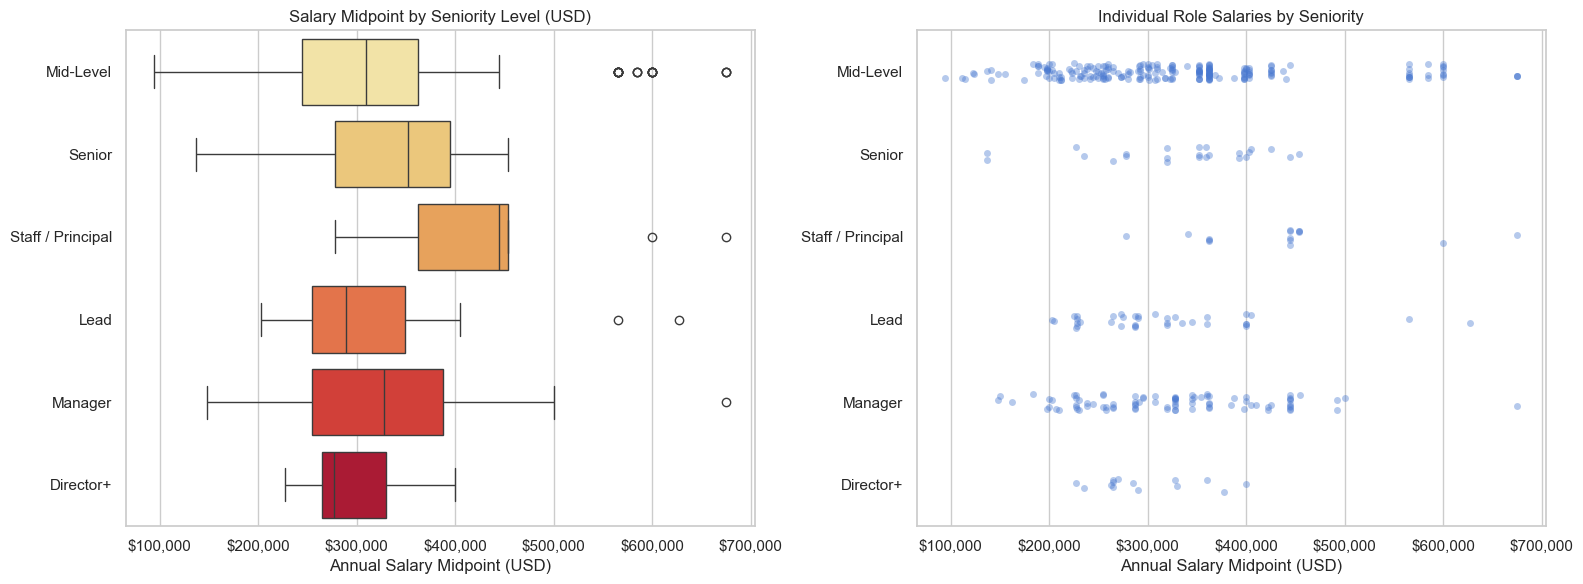

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot by seniority
sns.boxplot(
    data=df_salary, y="seniority", x="mid_usd",
    order=existing, ax=axes[0], palette="YlOrRd",
)
axes[0].set_title("Salary Midpoint by Seniority Level (USD)")
axes[0].set_xlabel("Annual Salary Midpoint (USD)")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Strip plot for granularity
sns.stripplot(
    data=df_salary, y="seniority", x="mid_usd",
    order=existing, ax=axes[1], alpha=0.4, jitter=True, size=5,
)
axes[1].set_title("Individual Role Salaries by Seniority")
axes[1].set_xlabel("Annual Salary Midpoint (USD)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.show()

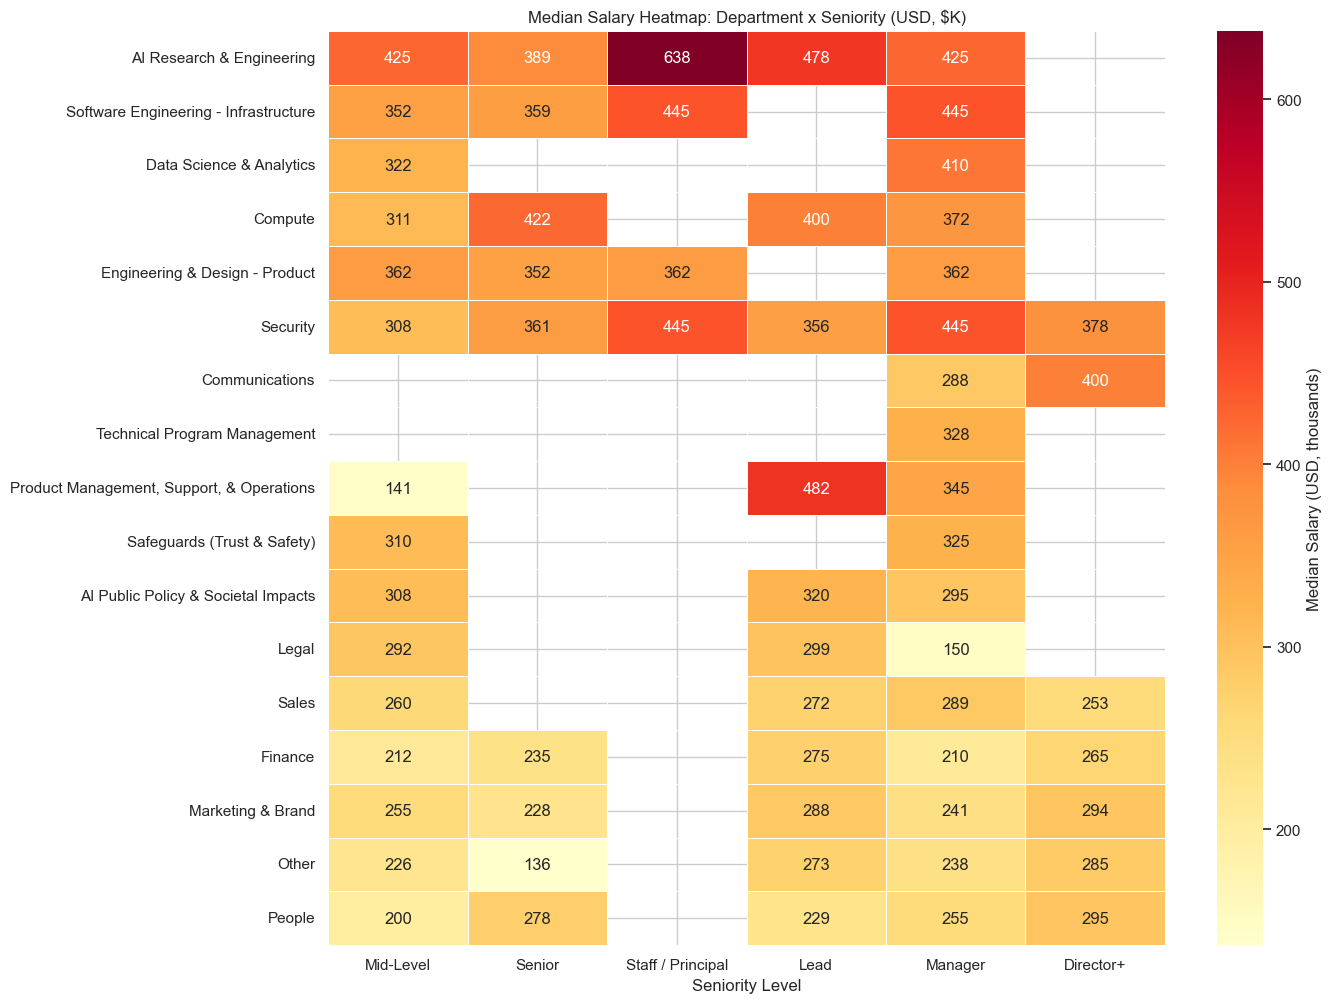

In [19]:
# Heatmap: median salary by department x seniority
pivot = df_salary.pivot_table(
    values="mid_usd", index="department", columns="seniority",
    aggfunc="median",
)
# Reorder columns by seniority
pivot = pivot.reindex(columns=[s for s in seniority_order if s in pivot.columns])
# Reorder rows by overall median
pivot = pivot.reindex(
    df_salary.groupby("department")["mid_usd"].median().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(14, max(8, len(pivot) * 0.6)))
sns.heatmap(
    pivot / 1000, annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Median Salary (USD, thousands)"},
    mask=pivot.isna(),
)
ax.set_title("Median Salary Heatmap: Department x Seniority (USD, $K)")
ax.set_xlabel("Seniority Level")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8. Remote vs On-Site Analysis

Compare salary ranges between remote-friendly roles and office-only positions.

In [20]:
# Classify work mode using rules from classify.py
df_salary["work_mode"] = df_salary["location"].apply(classify_work_mode)
df["work_mode"] = df["location"].apply(classify_work_mode)

print("WORK MODE DISTRIBUTION")
print("=" * 50)
for mode in ["Remote-Friendly", "Office-Only", "Unknown"]:
    total = (df["work_mode"] == mode).sum()
    with_sal = (df_salary["work_mode"] == mode).sum()
    if with_sal > 0:
        med = df_salary.loc[df_salary["work_mode"] == mode, "mid_usd"].median()
        print(f"  {mode:<18s} {total:>4d} total roles | {with_sal:>4d} with salary | median ${med:>10,.0f}")
    else:
        print(f"  {mode:<18s} {total:>4d} total roles | {with_sal:>4d} with salary")

WORK MODE DISTRIBUTION
  Remote-Friendly      34 total roles |   32 with salary | median $   310,000
  Office-Only         408 total roles |  365 with salary | median $   322,500
  Unknown               0 total roles |    0 with salary


/var/folders/gh/f625wpc923vbcdd7w3q2v6d40000gn/T/ipykernel_25136/3741042010.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mode_data, x="work_mode", y="mid_usd", ax=axes[0], palette="Set2")


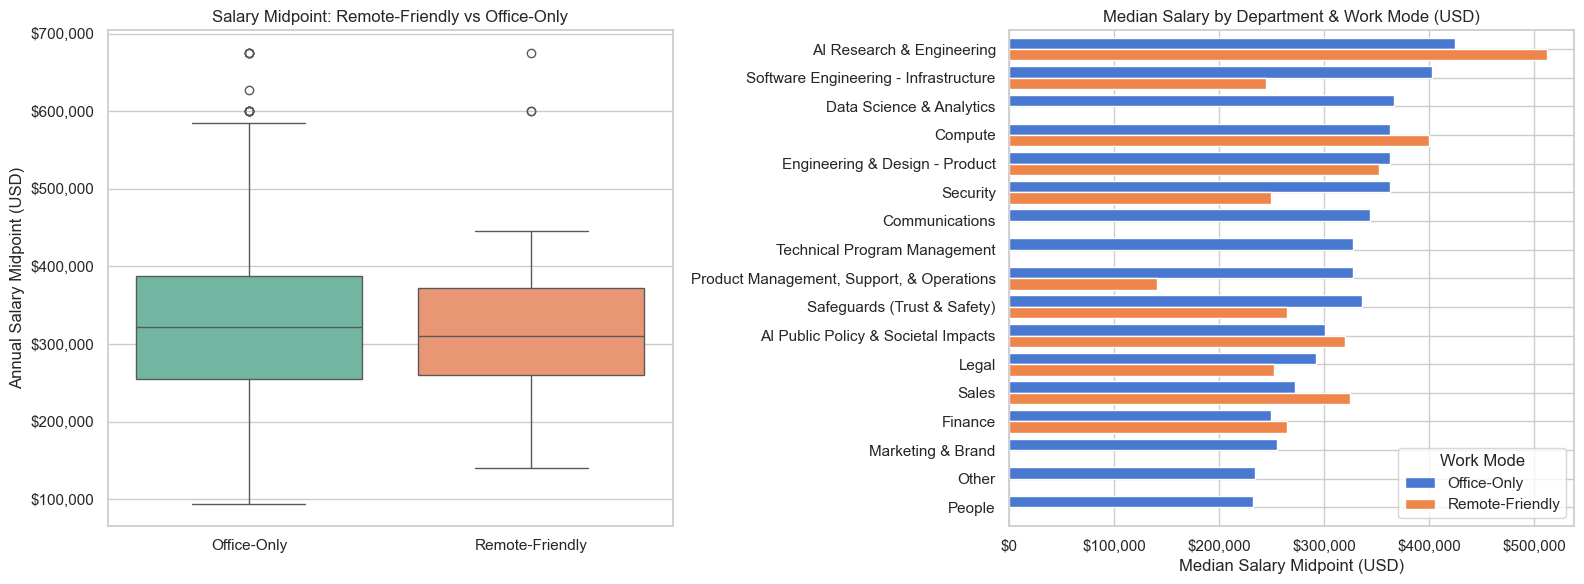

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall comparison
mode_data = df_salary[df_salary["work_mode"].isin(["Remote-Friendly", "Office-Only"])]
sns.boxplot(data=mode_data, x="work_mode", y="mid_usd", ax=axes[0], palette="Set2")
axes[0].set_title("Salary Midpoint: Remote-Friendly vs Office-Only")
axes[0].set_xlabel("")
axes[0].set_ylabel("Annual Salary Midpoint (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# By department + work mode
dept_mode = mode_data.groupby(["department", "work_mode"])["mid_usd"].median().unstack()
dept_mode = dept_mode.reindex(
    mode_data.groupby("department")["mid_usd"].median().sort_values(ascending=False).index
)
dept_mode.plot.barh(ax=axes[1], width=0.8)
axes[1].set_title("Median Salary by Department & Work Mode (USD)")
axes[1].set_xlabel("Median Salary Midpoint (USD)")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].legend(title="Work Mode")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Summary Dashboard

Key metrics and a combined view of the most important dimensions.

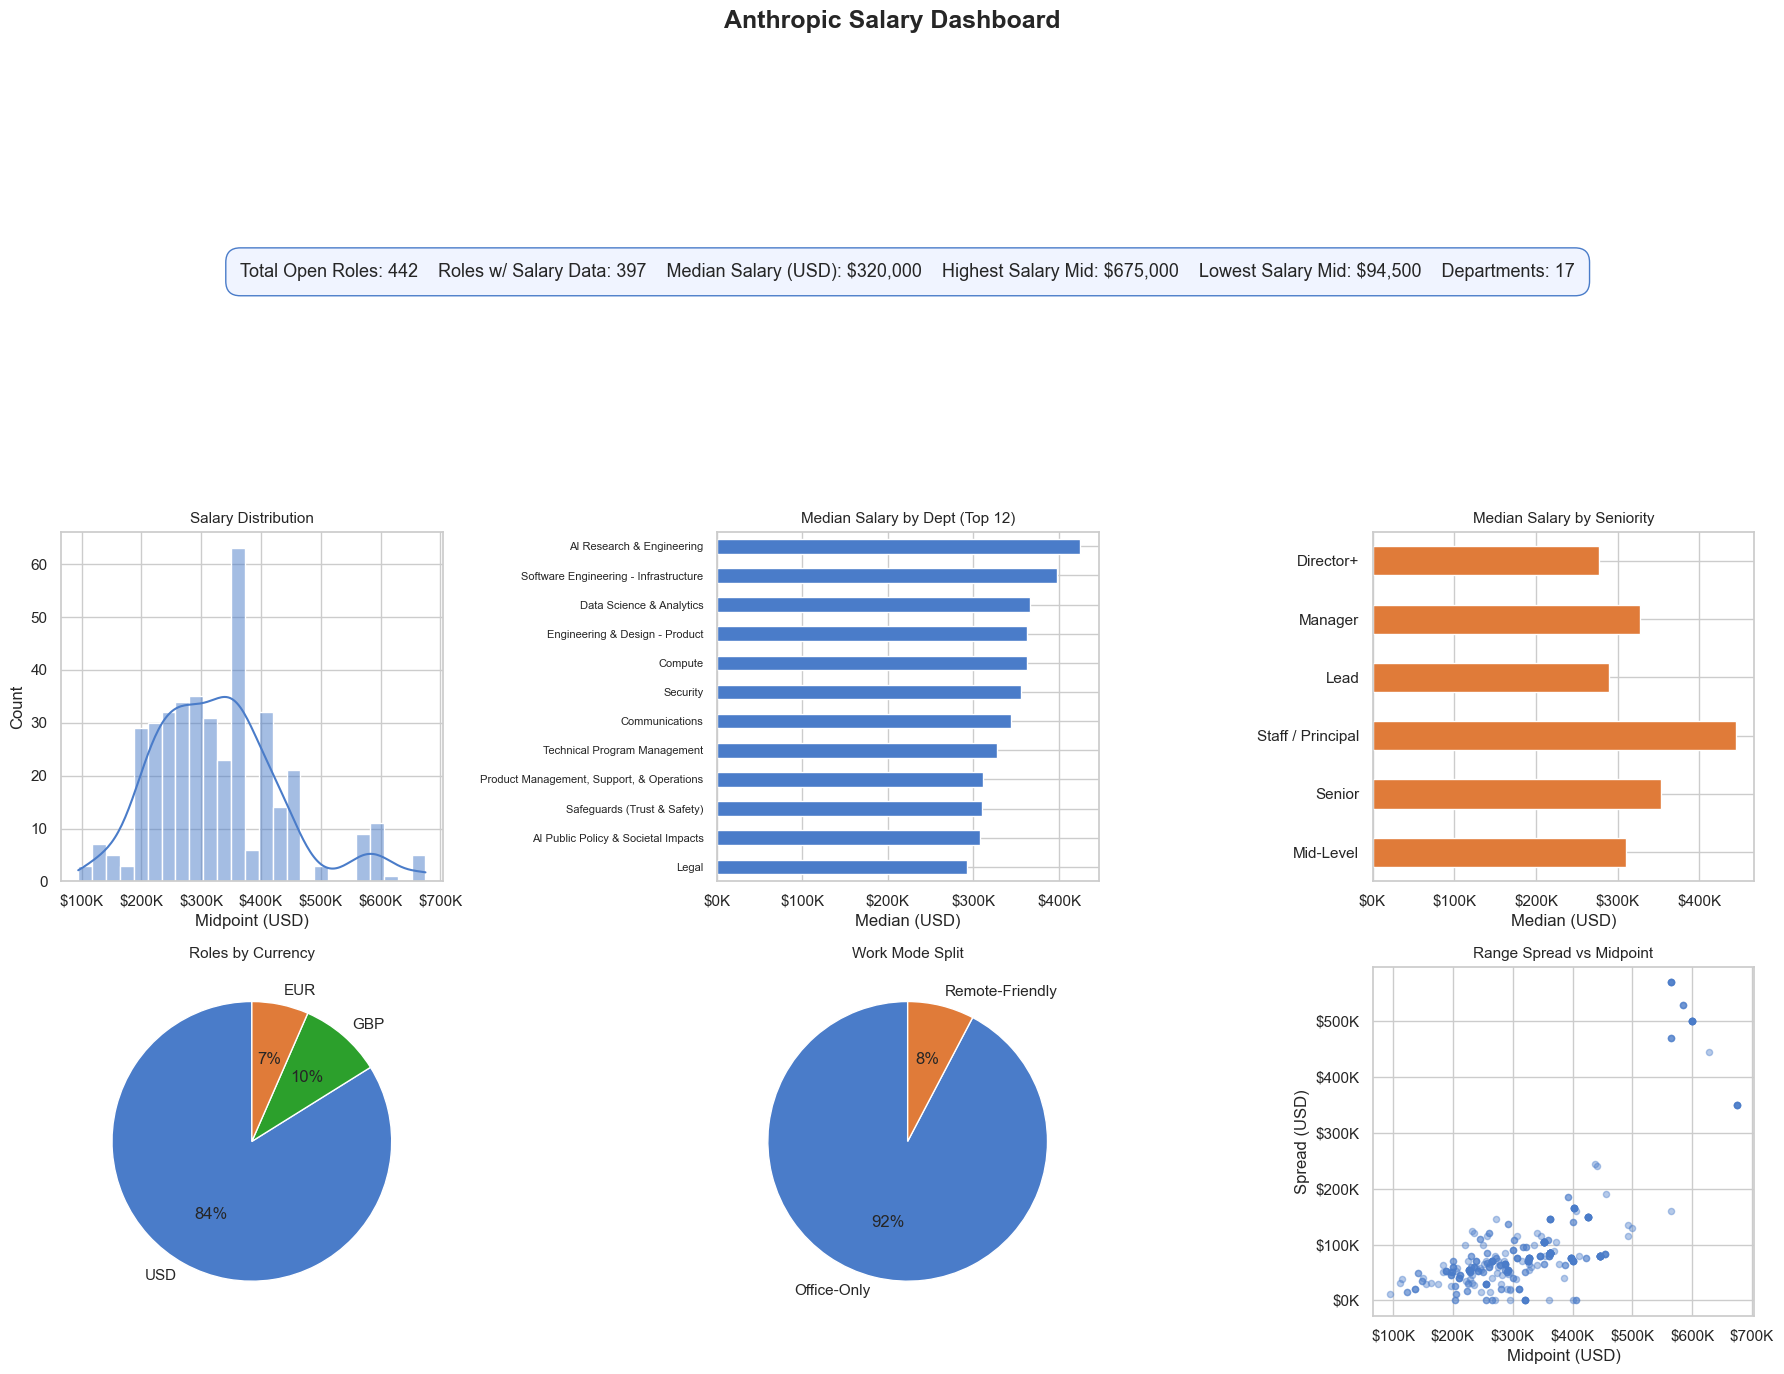

In [22]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Anthropic Salary Dashboard", fontsize=18, fontweight="bold", y=0.98)

# --- Panel 1: KPI text ---
ax_kpi = fig.add_subplot(3, 3, (1, 3))
ax_kpi.axis("off")
kpis = {
    "Total Open Roles": f"{len(df):,}",
    "Roles w/ Salary Data": f"{len(df_salary):,}",
    "Median Salary (USD)": f"${df_salary['mid_usd'].median():,.0f}",
    "Highest Salary Mid": f"${df_salary['mid_usd'].max():,.0f}",
    "Lowest Salary Mid": f"${df_salary['mid_usd'].min():,.0f}",
    "Departments": f"{df_salary['department'].nunique()}",
}
kpi_text = "    ".join(f"{k}: {v}" for k, v in kpis.items())
ax_kpi.text(0.5, 0.5, kpi_text, ha="center", va="center", fontsize=13,
            bbox=dict(boxstyle="round,pad=0.8", facecolor="#f0f4ff", edgecolor="#4a7cc9"))

# --- Panel 2: Distribution ---
ax_dist = fig.add_subplot(3, 3, 4)
sns.histplot(df_salary["mid_usd"], bins=25, kde=True, ax=ax_dist, color="#4a7cc9")
ax_dist.set_title("Salary Distribution", fontsize=11)
ax_dist.set_xlabel("Midpoint (USD)")
ax_dist.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

# --- Panel 3: Top departments ---
ax_dept = fig.add_subplot(3, 3, 5)
top_depts = df_salary.groupby("department")["mid_usd"].median().sort_values(ascending=True).tail(12)
top_depts.plot.barh(ax=ax_dept, color="#4a7cc9")
ax_dept.set_title("Median Salary by Dept (Top 12)", fontsize=11)
ax_dept.set_xlabel("Median (USD)")
ax_dept.set_ylabel("")
ax_dept.tick_params(axis="y", labelsize=8)
ax_dept.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

# --- Panel 4: Seniority ---
ax_sen = fig.add_subplot(3, 3, 6)
sen_med = df_salary.groupby("seniority")["mid_usd"].median().reindex(existing)
sen_med.plot.barh(ax=ax_sen, color="#e07b39")
ax_sen.set_title("Median Salary by Seniority", fontsize=11)
ax_sen.set_xlabel("Median (USD)")
ax_sen.set_ylabel("")
ax_sen.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

# --- Panel 5: Currency split ---
ax_cur = fig.add_subplot(3, 3, 7)
cur_counts = df_salary["currency"].value_counts()
ax_cur.pie(cur_counts, labels=cur_counts.index, autopct="%1.0f%%", startangle=90,
           colors=["#4a7cc9", "#2ca02c", "#e07b39"])
ax_cur.set_title("Roles by Currency", fontsize=11)

# --- Panel 6: Work mode ---
ax_wm = fig.add_subplot(3, 3, 8)
wm_counts = df["work_mode"].value_counts()
ax_wm.pie(wm_counts, labels=wm_counts.index, autopct="%1.0f%%", startangle=90,
          colors=["#4a7cc9", "#e07b39", "#999999"])
ax_wm.set_title("Work Mode Split", fontsize=11)

# --- Panel 7: Range spread vs midpoint ---
ax_spread = fig.add_subplot(3, 3, 9)
ax_spread.scatter(df_salary["mid_usd"], df_salary["range_usd"], alpha=0.4, s=20, c="#4a7cc9")
ax_spread.set_title("Range Spread vs Midpoint", fontsize=11)
ax_spread.set_xlabel("Midpoint (USD)")
ax_spread.set_ylabel("Spread (USD)")
ax_spread.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax_spread.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---

**NLP analysis** has been moved to `analyze_nlp.ipynb`.

**Historical analysis** has been moved to `analyze_historical.ipynb`.

Shared classification utilities are in `classify.py`.